In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv('hospital_patients_raw_world.csv')

In [91]:
df.head()

,PatientID,Age,Gender,Diagnosis,AdmissionDate,DischargeDate,HospitalID
0,PN-2021066,7.0,Other,Myocardial Infarction,2024-03-23,2024-03-29,HOSP-65
1,PN-4606019,36.0,Other,Pneumonia,2024-08-01,2024-08-07,HOSP-79
2,PN-2594016,70.0,Other,Influenza,2024-11-16,2024-11-23,HOSP-27
3,PN-6906914,90.0,Unknown,Acute Bronchitis,2025-07-05,2025-07-10,HOSP-64
4,PN-4656204,0.0,Female,Type 2 Diabetes,2023-08-30,2023-08-31,HOSP-31


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      5000 non-null   object 
 1   Age            4650 non-null   float64
 2   Gender         4650 non-null   object 
 3   Diagnosis      4650 non-null   object 
 4   AdmissionDate  5000 non-null   object 
 5   DischargeDate  5000 non-null   object 
 6   HospitalID     5000 non-null   object 
dtypes: float64(1), object(6)
memory usage: 273.6+ KB


In [93]:
print('No of Dupicate rows found',df.duplicated().sum())

No of Dupicate rows found 0


In [94]:
missing_values = df.isna().sum()
persentage_of_missing_values = (missing_values / len(df))*100

missing_info = pd.Series(persentage_of_missing_values).sort_values(ascending = False)

print('Persentage of missing values per column:')
print(missing_info[missing_info > 0])

Persentage of missing values per column:
Age          7.0
Gender       7.0
Diagnosis    7.0
dtype: float64


In [95]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

print(f"Missing values in 'Age' column after imputation: {df['Age'].isnull().sum()}")

Missing values in 'Age' column after imputation: 0


In [96]:
mode_gender = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(mode_gender)

print(f"Missing values in 'Gender' column after imputation: {df['Gender'].isnull().sum()}")

Missing values in 'Gender' column after imputation: 0


In [97]:
mode_diagnosis = df['Diagnosis'].mode()[0]
df['Diagnosis'] = df['Diagnosis'].fillna(mode_diagnosis)

print(f"Missing values in 'Diagnosis' column after imputation: {df['Diagnosis'].isnull().sum()}")

Missing values in 'Diagnosis' column after imputation: 0


In [98]:
df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'], errors = 'coerce')
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'], errors = 'coerce')
df[['AdmissionDate', 'DischargeDate']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   AdmissionDate  5000 non-null   datetime64[ns]
 1   DischargeDate  5000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 78.3 KB


In [99]:
df['Gender'] = df['Gender'].astype('category')
df['Diagnosis'] = df['Diagnosis'].astype('category')
df['HospitalID'] = df['HospitalID'].astype('category')
df[['Gender', 'Diagnosis', 'HospitalID']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Gender      5000 non-null   category
 1   Diagnosis   5000 non-null   category
 2   HospitalID  5000 non-null   category
dtypes: category(3)
memory usage: 19.0 KB


In [100]:
print("Unique values in 'Gender' column:")
print(df['Gender'].unique())

print("\nUnique values in 'Diagnosis' column:")
print(df['Diagnosis'].unique())

print("\nUnique values in 'HospitalID' column:")
print(df['HospitalID'].unique())

Unique values in 'Gender' column:
['Other', 'Unknown', 'Female', 'Male']
Categories (4, object): ['Female', 'Male', 'Other', 'Unknown']

Unique values in 'Diagnosis' column:
['Myocardial Infarction', 'Pneumonia', 'Influenza', 'Acute Bronchitis', 'Type 2 Diabetes', ..., 'ACUTE BRONCHITIS', 'CHRONIC KIDNEY DISEASE', 'ATRIAL FIBRILLATION', 'MYOCARDIAL INFARCTION', 'OSTEOARTHRITIS']
Length: 28
Categories (28, object): ['ACUTE BRONCHITIS', 'ASTHMA', 'ATRIAL FIBRILLATION', 'Acute Bronchitis', ..., 'TYPE 2 DIABETES', 'Type 2 Diabetes', 'URINARY TRACT INFECTION', 'Urinary Tract Infection']

Unique values in 'HospitalID' column:
['HOSP-65', 'HOSP-79', 'HOSP-27', 'HOSP-64', 'HOSP-31', ..., 'HOSP-30', 'HOSP-86', 'HOSP-14', 'HOSP-12', 'HOSP-82']
Length: 90
Categories (90, object): ['HOSP-10', 'HOSP-11', 'HOSP-12', 'HOSP-13', ..., 'HOSP-96', 'HOSP-97', 'HOSP-98', 'HOSP-99']


In [101]:
df['Diagnosis'] = df['Diagnosis'].apply(lambda x: x.title() if isinstance(x, str) else x)

print("Unique values in 'Diagnosis' column after standardization:")
print(df['Diagnosis'].unique())

Unique values in 'Diagnosis' column after standardization:
['Myocardial Infarction' 'Pneumonia' 'Influenza' 'Acute Bronchitis'
 'Type 2 Diabetes' 'Gastroenteritis' 'Urinary Tract Infection'
 'Diverticulitis' 'Cholelithiasis' 'Hypertension' 'Chronic Kidney Disease'
 'Atrial Fibrillation' 'Asthma' 'Osteoarthritis']


In [102]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
print(Q1)
print(Q3)

25.0
70.0


In [103]:
IQR = Q3 - Q1
lower_bound = Q1 - (1.5*IQR)
upper_bound = Q3 + (1.5*IQR)
print(f'IQR: {IQR}')
print(f'Upper Bound: {upper_bound}')
print(f'Lower Bound: {lower_bound}')

IQR: 45.0
Upper Bound: 137.5
Lower Bound: -42.5


In [104]:
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print(f'Number of outliers in Age column {len(outliers)}')

Number of outliers in Age column 0


In [105]:
df['Age'] = df['Age'].clip(lower= lower_bound, upper= upper_bound)


In [106]:
mismatch_dates = df[df['DischargeDate'] < df['AdmissionDate']]
print(f'Number of row where Discharge date is earlier then Admission Date: {len(mismatch_dates)}')
if not mismatch_dates.empty:
    print("First 5 rows with mismatched dates:")
    print(mismatch_dates.head())

Number of row where Discharge date is earlier then Admission Date: 150
First 5 rows with mismatched dates:
      PatientID   Age   Gender              Diagnosis AdmissionDate  \
23   PN-7210811  74.0   Female                 Asthma    2026-01-13   
26   PN-2216893  87.0  Unknown  Myocardial Infarction    2024-06-04   
41   PN-2075665  47.0    Other         Osteoarthritis    2023-07-25   
47   PN-4853042  51.0    Other         Osteoarthritis    2024-01-12   
105  PN-6682504  38.0  Unknown       Acute Bronchitis    2025-06-25   

    DischargeDate HospitalID  
23     2026-01-08    HOSP-21  
26     2024-05-30    HOSP-19  
41     2023-07-20    HOSP-53  
47     2024-01-07    HOSP-11  
105    2025-06-20    HOSP-69  


In [107]:
mask = df['DischargeDate'] < df['AdmissionDate']
df.loc[mask, ['AdmissionDate', 'DischargeDate']] = df.loc[mask, ['DischargeDate', 'AdmissionDate']].values # Swaping between values of Admission Date and Discharge Date

print(f"Number of rows where DischargeDate is earlier than AdmissionDate after swap: {df[df['DischargeDate'] < df['AdmissionDate']].shape[0]}")
print("First 5 rows of DataFrame after swapping dates:")
print(df.head())

Number of rows where DischargeDate is earlier than AdmissionDate after swap: 0
First 5 rows of DataFrame after swapping dates:
    PatientID   Age   Gender              Diagnosis AdmissionDate  \
0  PN-2021066   7.0    Other  Myocardial Infarction    2024-03-23   
1  PN-4606019  36.0    Other              Pneumonia    2024-08-01   
2  PN-2594016  70.0    Other              Influenza    2024-11-16   
3  PN-6906914  90.0  Unknown       Acute Bronchitis    2025-07-05   
4  PN-4656204   0.0   Female        Type 2 Diabetes    2023-08-30   

  DischargeDate HospitalID  
0    2024-03-29    HOSP-65  
1    2024-08-07    HOSP-79  
2    2024-11-23    HOSP-27  
3    2025-07-10    HOSP-64  
4    2023-08-31    HOSP-31  


In [108]:
today = pd.Timestamp.now().normalize()
# Identify future admission dates
future_admission_mask = df['AdmissionDate'] > today
print(f"Number of future AdmissionDates: {future_admission_mask.sum()}")

# Identify future discharge dates
future_discharge_mask = df['DischargeDate'] > today
print(f"Number of future DischargeDates: {future_discharge_mask.sum()}")

# Set future dates to NaT
df.loc[future_admission_mask, 'AdmissionDate'] = pd.NaT
df.loc[future_discharge_mask, 'DischargeDate'] = pd.NaT

print("Dates checked and future dates set to NaT.")
print("DataFrame info after handling future dates:")
df[['AdmissionDate', 'DischargeDate']].info()


Number of future AdmissionDates: 0
Number of future DischargeDates: 0
Dates checked and future dates set to NaT.
DataFrame info after handling future dates:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   AdmissionDate  5000 non-null   datetime64[ns]
 1   DischargeDate  5000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 78.3 KB


In [109]:
df['LengthOfStay'] = (df['DischargeDate'] - df['AdmissionDate']).dt.days

print("First 5 rows of DataFrame with new 'LengthOfStay' column:")
print(df.head())

First 5 rows of DataFrame with new 'LengthOfStay' column:
    PatientID   Age   Gender              Diagnosis AdmissionDate  \
0  PN-2021066   7.0    Other  Myocardial Infarction    2024-03-23   
1  PN-4606019  36.0    Other              Pneumonia    2024-08-01   
2  PN-2594016  70.0    Other              Influenza    2024-11-16   
3  PN-6906914  90.0  Unknown       Acute Bronchitis    2025-07-05   
4  PN-4656204   0.0   Female        Type 2 Diabetes    2023-08-30   

  DischargeDate HospitalID  LengthOfStay  
0    2024-03-29    HOSP-65             6  
1    2024-08-07    HOSP-79             6  
2    2024-11-23    HOSP-27             7  
3    2025-07-10    HOSP-64             5  
4    2023-08-31    HOSP-31             1  


In [110]:
print("Unique values in 'Gender' column:")
print(df['Gender'].unique())

print("\nUnique values in 'Diagnosis' column:")
print(df['Diagnosis'].unique())

Unique values in 'Gender' column:
['Other', 'Unknown', 'Female', 'Male']
Categories (4, object): ['Female', 'Male', 'Other', 'Unknown']

Unique values in 'Diagnosis' column:
['Myocardial Infarction' 'Pneumonia' 'Influenza' 'Acute Bronchitis'
 'Type 2 Diabetes' 'Gastroenteritis' 'Urinary Tract Infection'
 'Diverticulitis' 'Cholelithiasis' 'Hypertension' 'Chronic Kidney Disease'
 'Atrial Fibrillation' 'Asthma' 'Osteoarthritis']


In [111]:
print("DataFrame Info after all cleaning operations:")
df.info()

print("\nDataFrame Descriptive Statistics after all cleaning operations:")
print(df.describe())

DataFrame Info after all cleaning operations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   PatientID      5000 non-null   object        
 1   Age            5000 non-null   float64       
 2   Gender         5000 non-null   category      
 3   Diagnosis      5000 non-null   object        
 4   AdmissionDate  5000 non-null   datetime64[ns]
 5   DischargeDate  5000 non-null   datetime64[ns]
 6   HospitalID     5000 non-null   category      
 7   LengthOfStay   5000 non-null   int64         
dtypes: category(2), datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 247.2+ KB

DataFrame Descriptive Statistics after all cleaning operations:
              Age                  AdmissionDate               DischargeDate  \
count  5000.00000                           5000                        5000   
mean     47.35740

In [112]:
df['LengthOfStay_log'] = np.log1p(df['LengthOfStay'])

print("First 5 rows of DataFrame with new 'LengthOfStay_log' column:")
print(df[['LengthOfStay', 'LengthOfStay_log']].head())

First 5 rows of DataFrame with new 'LengthOfStay_log' column:
   LengthOfStay  LengthOfStay_log
0             6          1.945910
1             6          1.945910
2             7          2.079442
3             5          1.791759
4             1          0.693147


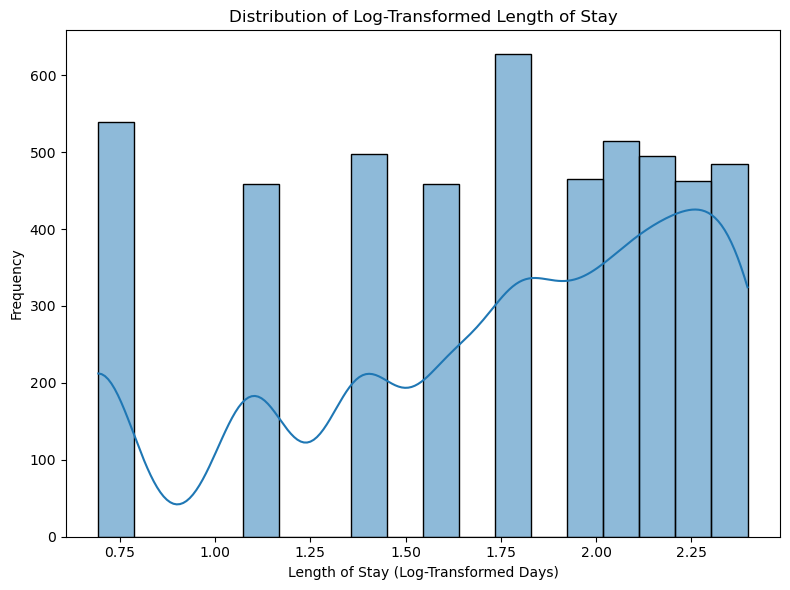

In [113]:
plt.figure(figsize=(8, 6))
sns.histplot(df['LengthOfStay_log'], kde=True)
plt.title('Distribution of Log-Transformed Length of Stay')
plt.xlabel('Length of Stay (Log-Transformed Days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

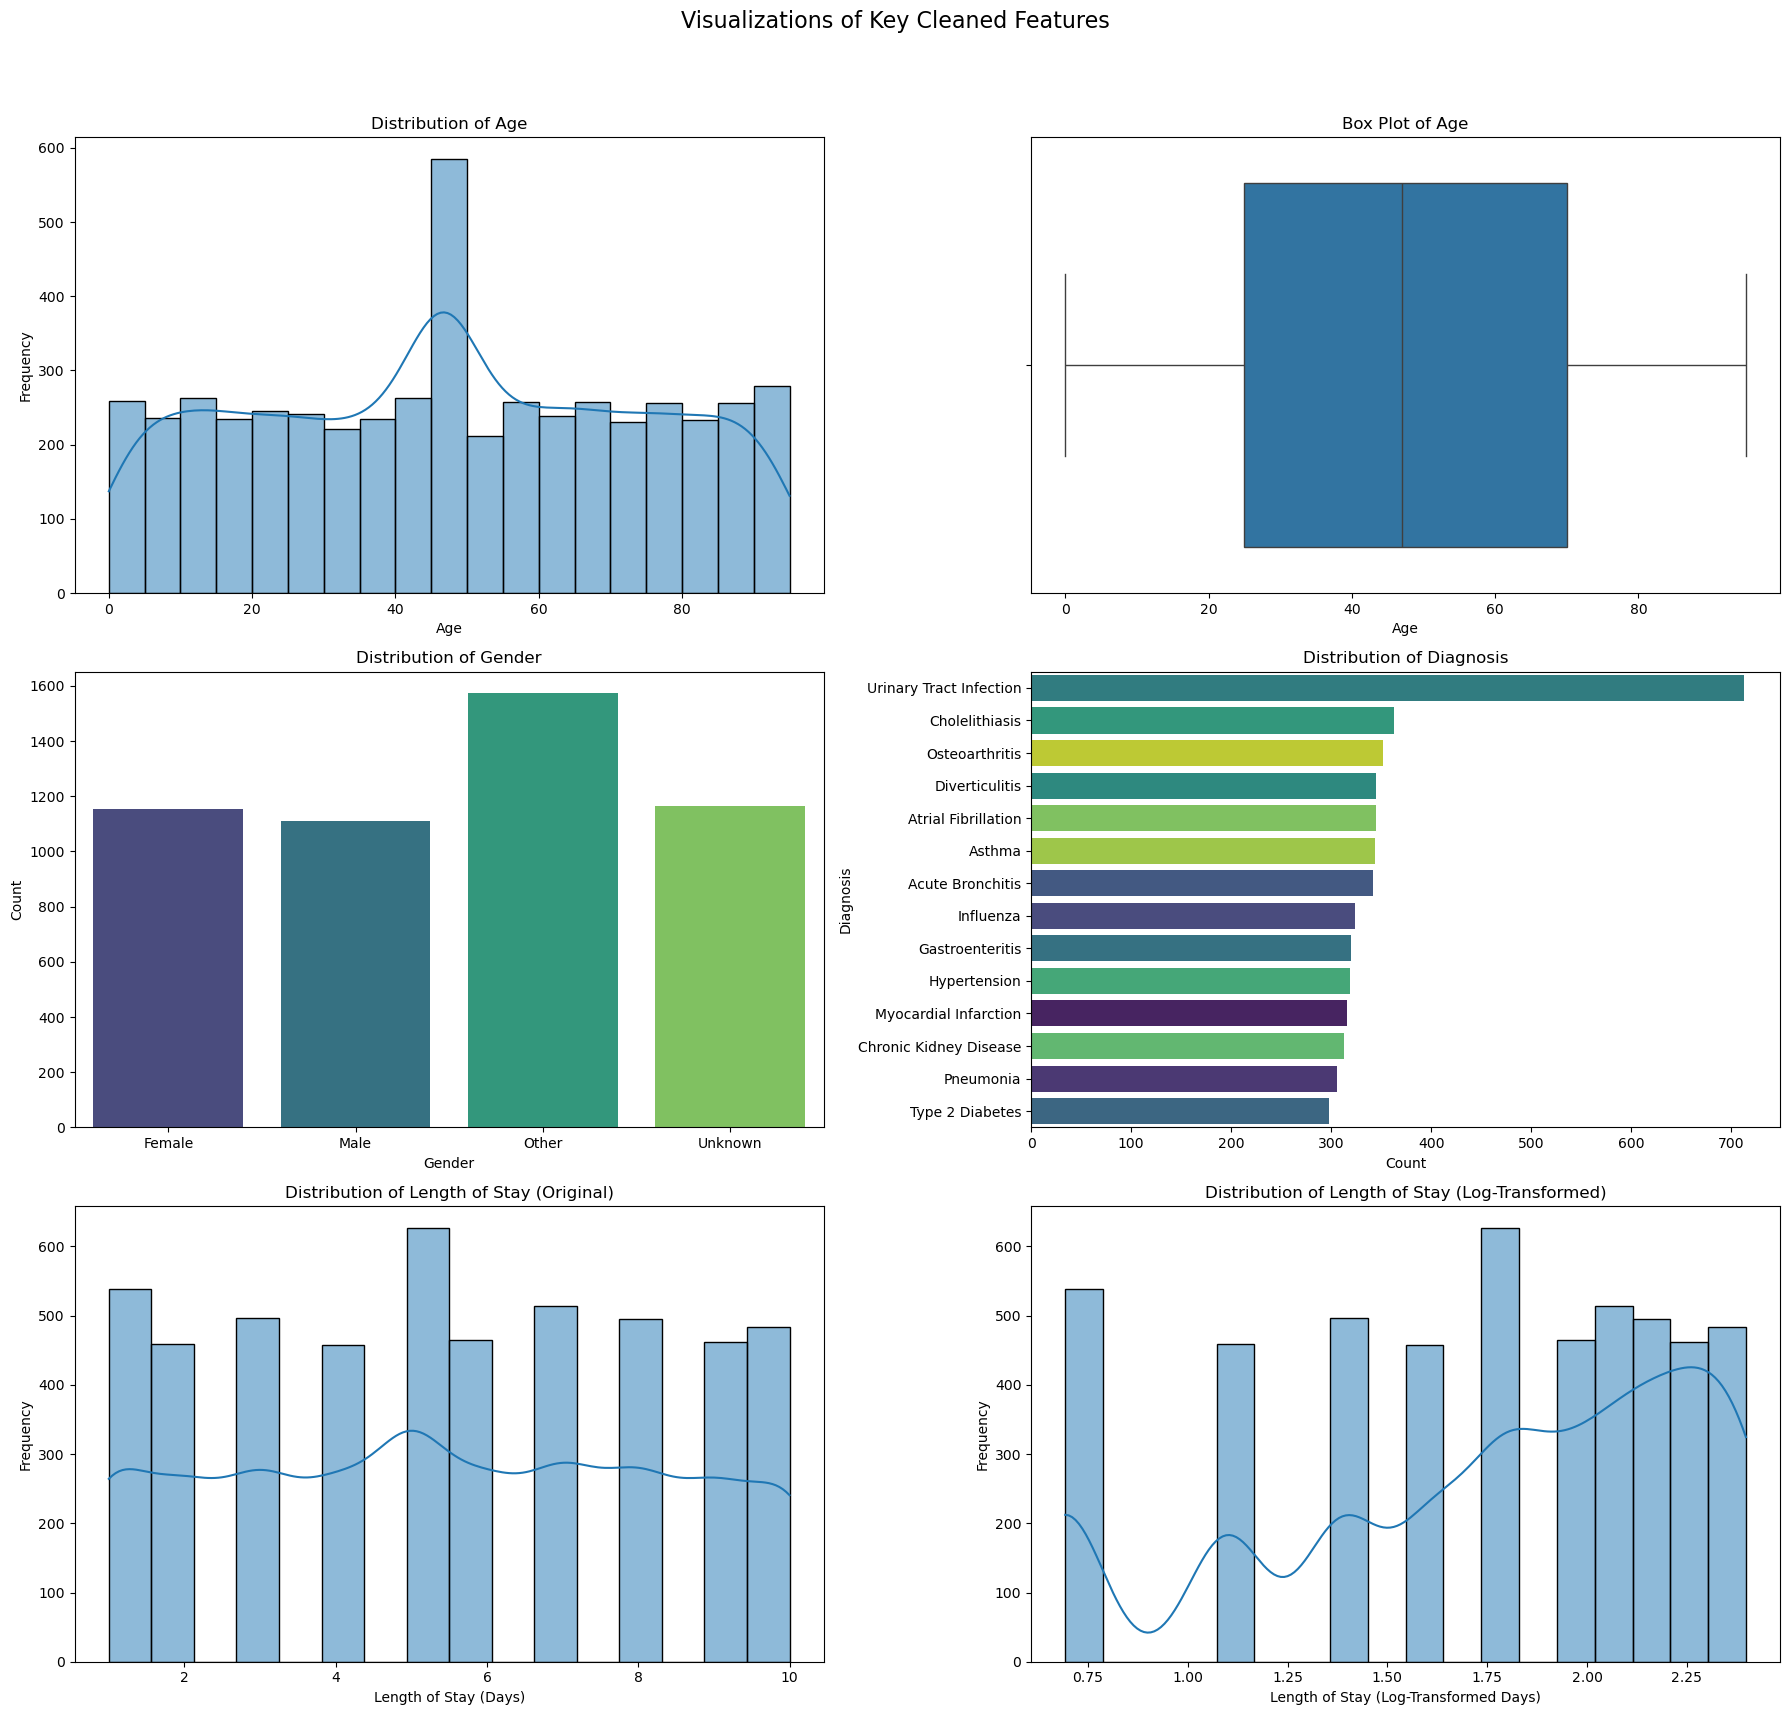

In [114]:
# Create a figure with multiple subplots for better organization
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
fig.suptitle('Visualizations of Key Cleaned Features', fontsize=16)

# Plot for 'Age' - Histogram with KDE
sns.histplot(df['Age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Plot for 'Age' - Box plot (to identify outliers visually)
sns.boxplot(x=df['Age'], ax=axes[0, 1])
axes[0, 1].set_title('Box Plot of Age')
axes[0, 1].set_xlabel('Age')

# Plot for 'Gender' - Count plot
sns.countplot(x=df['Gender'], hue=df['Gender'], ax=axes[1, 0], palette='viridis', legend=False)
axes[1, 0].set_title('Distribution of Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Count')

# Plot for 'Diagnosis' - Count plot
sns.countplot(y=df['Diagnosis'], hue=df['Diagnosis'], ax=axes[1, 1], order = df['Diagnosis'].value_counts().index, palette='viridis', legend=False) # Using y for better readability of many categories
axes[1, 1].set_title('Distribution of Diagnosis')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Diagnosis')
# plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha='right') # Only if x-axis labels were too long

# Plot for 'LengthOfStay' (original) - Histogram with KDE
sns.histplot(df['LengthOfStay'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Length of Stay (Original)')
axes[2, 0].set_xlabel('Length of Stay (Days)')
axes[2, 0].set_ylabel('Frequency')

# Plot for 'LengthOfStay_log' (log-transformed) - Histogram with KDE
sns.histplot(df['LengthOfStay_log'], kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Distribution of Length of Stay (Log-Transformed)')
axes[2, 1].set_xlabel('Length of Stay (Log-Transformed Days)')
axes[2, 1].set_ylabel('Frequency')



plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [115]:
df.head()

,PatientID,Age,Gender,Diagnosis,AdmissionDate,DischargeDate,HospitalID,LengthOfStay,LengthOfStay_log
0,PN-2021066,7.0,Other,Myocardial Infarction,2024-03-23,2024-03-29,HOSP-65,6,1.945910
1,PN-4606019,36.0,Other,Pneumonia,2024-08-01,2024-08-07,HOSP-79,6,1.945910
2,PN-2594016,70.0,Other,Influenza,2024-11-16,2024-11-23,HOSP-27,7,2.079442
3,PN-6906914,90.0,Unknown,Acute Bronchitis,2025-07-05,2025-07-10,HOSP-64,5,1.791759
4,PN-4656204,0.0,Female,Type 2 Diabetes,2023-08-30,2023-08-31,HOSP-31,1,0.693147


In [116]:
(df['Age'] == 0).sum()

np.int64(52)

In [117]:
df = df.drop(df[df['Age'] == 0].index)

In [118]:
df.head()

,PatientID,Age,Gender,Diagnosis,AdmissionDate,DischargeDate,HospitalID,LengthOfStay,LengthOfStay_log
0,PN-2021066,7.0,Other,Myocardial Infarction,2024-03-23,2024-03-29,HOSP-65,6,1.945910
1,PN-4606019,36.0,Other,Pneumonia,2024-08-01,2024-08-07,HOSP-79,6,1.945910
2,PN-2594016,70.0,Other,Influenza,2024-11-16,2024-11-23,HOSP-27,7,2.079442
3,PN-6906914,90.0,Unknown,Acute Bronchitis,2025-07-05,2025-07-10,HOSP-64,5,1.791759
5,PN-1777766,15.0,Unknown,Gastroenteritis,2024-08-09,2024-08-15,HOSP-17,6,1.945910


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4948 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PatientID         4948 non-null   object        
 1   Age               4948 non-null   float64       
 2   Gender            4948 non-null   category      
 3   Diagnosis         4948 non-null   object        
 4   AdmissionDate     4948 non-null   datetime64[ns]
 5   DischargeDate     4948 non-null   datetime64[ns]
 6   HospitalID        4948 non-null   category      
 7   LengthOfStay      4948 non-null   int64         
 8   LengthOfStay_log  4948 non-null   float64       
dtypes: category(2), datetime64[ns](2), float64(2), int64(1), object(2)
memory usage: 321.9+ KB


In [120]:
df.to_csv('cleaned_hospital_patient_data.csv')